In [ ]:
# Initial

import pandas as pd
import matplotlib.pyplot as plt

# Load data, make sure UTC
ec_csv = r"C:\Users\edwar\OneDrive\Desktop\CRREL_GH\data\processed\storm_mid_feb_ec.csv"
ec_df = pd.read_csv(ec_csv)
ec_df['timestamp'] = pd.to_datetime(ec_df['timestamp']).dt.tz_convert('UTC')
ec_df = ec_df.sort_values(by='timestamp')
ec_df['date'] = ec_df['timestamp'].dt.date

# Set start and end date
start_date = pd.to_datetime('2026-02-13').tz_localize('-08:00')
end_date = pd.to_datetime('2026-02-27').tz_localize('-08:00')

# Load raw (non-elevation corrected) data
#r_csv = r"C:\Users\edwar\OneDrive\Desktop\CRREL_GH\data\processed\storm_mid_feb_raw.csv"
#r_df = pd.read_csv(r_csv)
#r_df['timestamp'] = pd.to_datetime(r_df['timestamp']).dt.tz_convert('UTC')

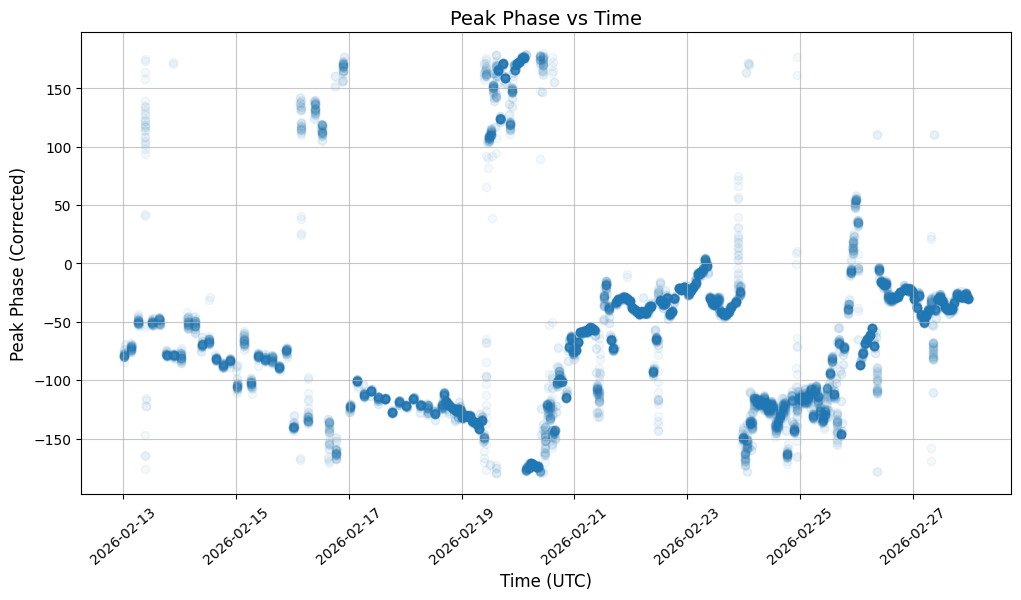

In [2]:
# SCATTER (raw optional, commented out)

#r_df['date'] = r_df['timestamp'].dt.date

plt.figure(figsize=(12, 6))
plt.scatter(ec_df['timestamp'], ec_df['peak_phase_deg'], alpha = 0.05)
#plt.scatter(r_df['timestamp'], r_df['peak_phase_deg'], color='orange', alpha = 0.05)

plt.title('Peak Phase vs Time', fontsize=14)
plt.xlabel('Time (UTC)', fontsize=12)
plt.ylabel('Peak Phase (Corrected)', fontsize=12)

plt.xticks(rotation=40)
plt.grid(True, alpha=0.7)
#plt.tight_layout()

###plt.savefig('phase_corrected.png')

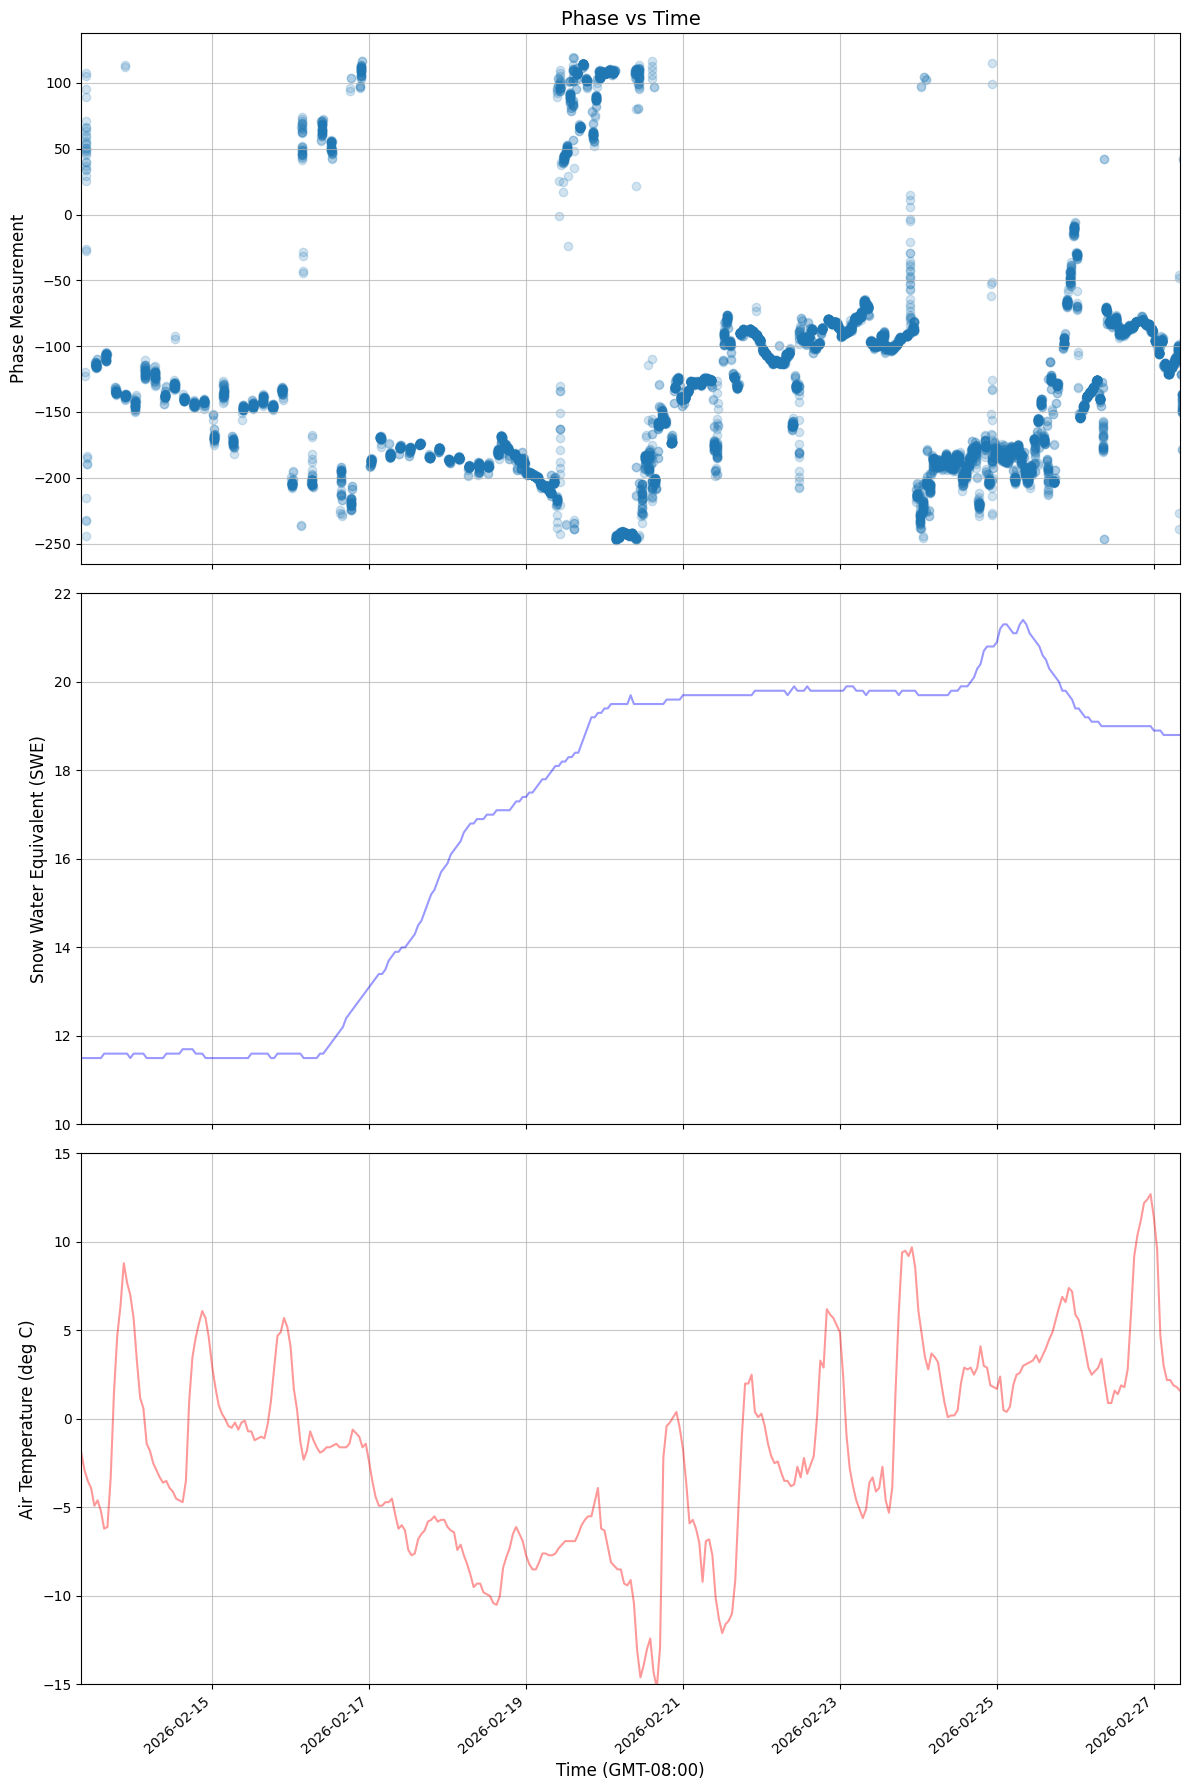

In [3]:
# SCATTER WITH SWE AND AIR TEMP BELOW


def prep_snotel_data(filepath):
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['Date']+ ' ' + df['Time']).dt.tz_localize('-08:00')
    return df

swe_path = r'C:\Users\edwar\OneDrive\Desktop\CRREL_GH\data\swe_cssl\nov25_mar26_SWE.csv'
temp_path = r'C:\Users\edwar\OneDrive\Desktop\CRREL_GH\data\airtemp_cssl\nov25_mar26_airtemp.csv'

swe_df = prep_snotel_data(swe_path)
temp_df = prep_snotel_data(temp_path)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

# Top Plot: Peak Phase
ax1.set_title('Phase vs Time', fontsize=14)
ax1.scatter(ec_df['timestamp'], ec_df['phase_corrected'], alpha=0.2)
ax1.set_ylabel('Phase Measurement', fontsize=12)
ax1.grid(True, alpha=0.7)
#ax1.set_ylim(-360,200)

# Middle plot: SWE
ax2.plot(swe_df['timestamp'], swe_df['WTEQ.I-1 (in) '], color='blue', linestyle='-', alpha =0.4)
ax2.set_ylabel('Snow Water Equivalent (SWE)', fontsize=12)
ax2.grid(True, alpha=0.7)
ax2.set_ylim(10,22)

# Bottom plot: Air Temp
ax3.plot(temp_df['timestamp'], temp_df['TOBS.I-1 (degC) '], color='red', linestyle='-', alpha =0.4)
ax3.set_ylabel('Air Temperature (deg C)', fontsize=12)
ax3.grid(True, alpha=0.7)
ax3.set_ylim(-15,15)

# X-Axis formatting

ax3.set_xlim(start_date,end_date)
plt.setp(ax3.get_xticklabels(), rotation=40, ha='right')
ax3.set_xlabel('Time (GMT-08:00)', fontsize=12)

plt.tight_layout()
plt.show()

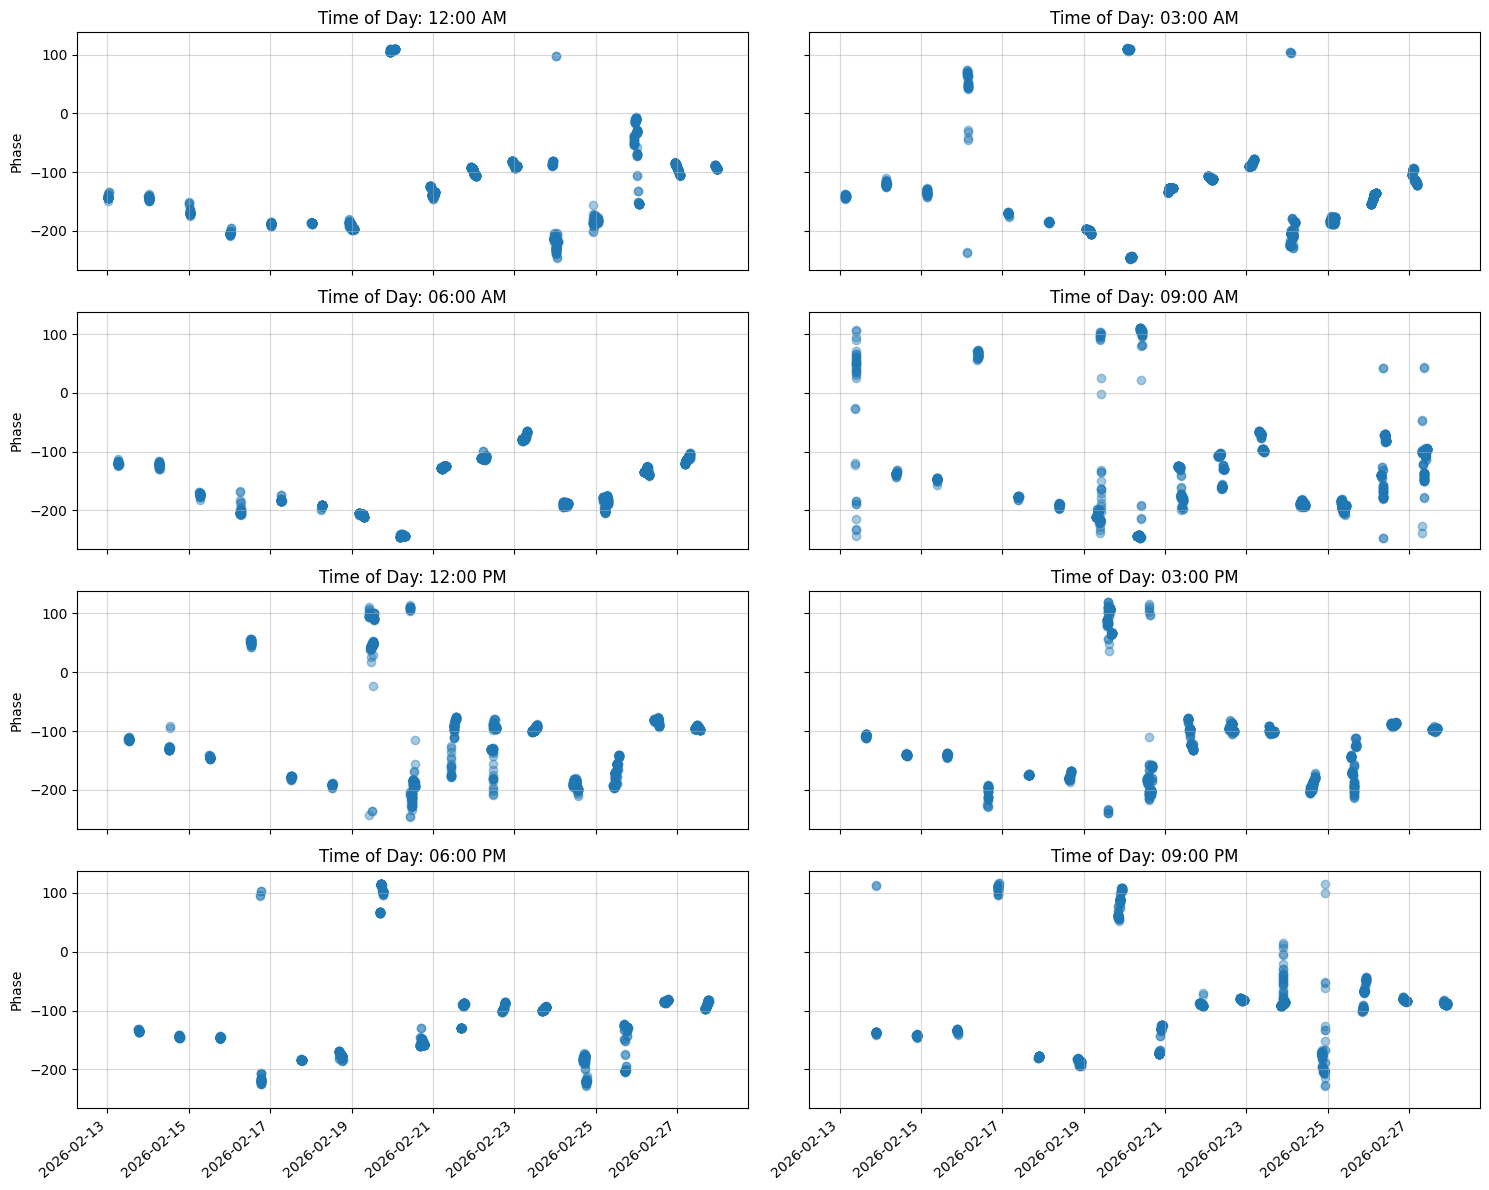

In [7]:
# SCATTER BY HOUR

ec_df['time_group'] = ec_df['timestamp'].dt.round('3h').dt.time
target_times = pd.date_range("00:00", "21:00", freq="3h").time

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, t_group in enumerate(target_times):
    subset = ec_df[ec_df['time_group'] == t_group]
    axes[i].scatter(subset['timestamp'], subset['phase_corrected'], 
                    alpha = 0.4)
    
    #axes[i].plot(subset['timestamp'], subset['phase_corrected'], 
                 #alpha=0.4, linestyle='--')
    
    time_str = t_group.strftime('%I:%M %p')
    axes[i].set_title(f'Time of Day: {time_str}', fontsize=12)
    
    axes[i].grid(True, alpha=0.5)
    
    if i % 2 == 0:
        axes[i].set_ylabel('Phase')

for ax in axes[-2:]: 
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.show()

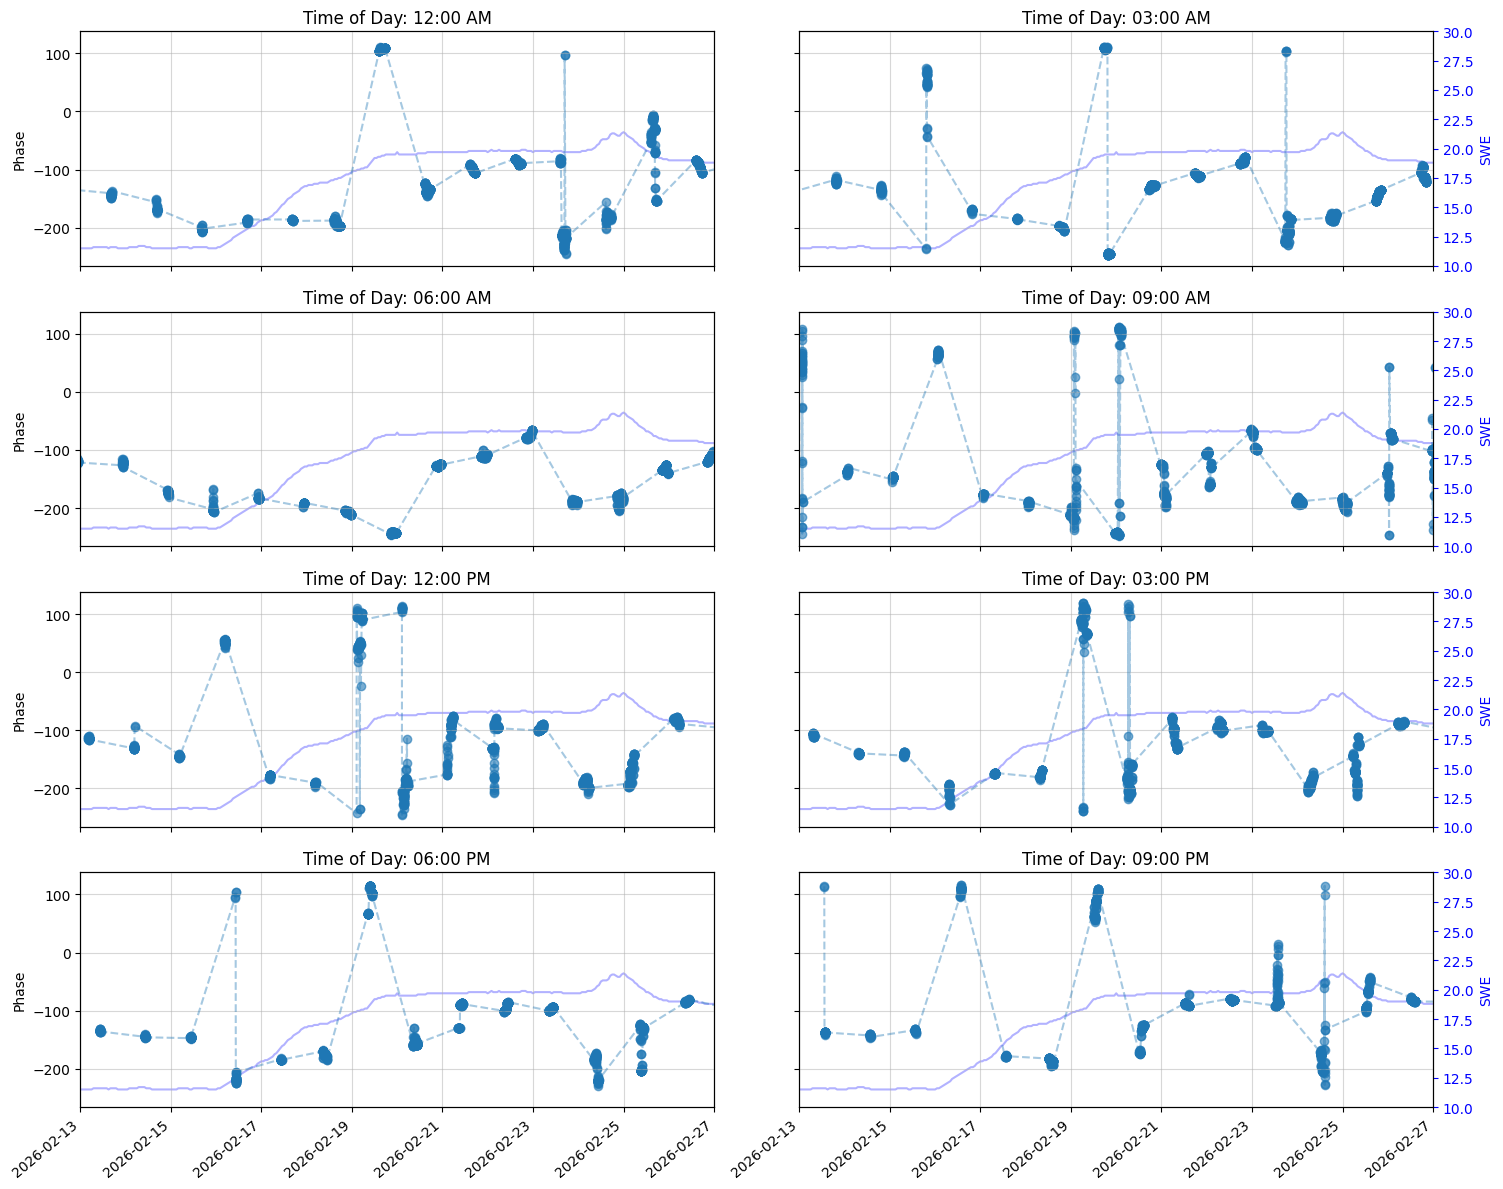

In [8]:
# SCATTER BY HOUR WITH SWE

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, t_group in enumerate(target_times):
    ax_swe = axes[i].twinx()
    
    ax_swe.plot(swe_df['timestamp'], swe_df['WTEQ.I-1 (in) '], color='blue', linestyle='-', alpha=0.3)
    ax_swe.set_ylim(10, 30) 
    
    if i % 2 == 0:  
        ax_swe.set_yticks([])
    else:
        ax_swe.set_ylabel('SWE', color='blue', fontsize=10)
        ax_swe.tick_params(axis='y', colors='blue')

    subset = ec_df[ec_df['time_group'] == t_group]
    
    axes[i].scatter(subset['timestamp'], subset['phase_corrected'], 
                    alpha=0.6)
    axes[i].plot(subset['timestamp'], subset['phase_corrected'], 
                 alpha=0.4, linestyle='--')
    
    time_str = t_group.strftime('%I:%M %p')
    axes[i].set_title(f'Time of Day: {time_str}', fontsize=12)
    axes[i].grid(True, alpha=0.5)
    
    if i % 2 == 0:
        axes[i].set_ylabel('Phase')

    axes[i].set_zorder(ax_swe.get_zorder() + 1)
    axes[i].patch.set_visible(False)

for ax in axes[-2:]: 
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
    
axes[0].set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

plt.tight_layout()
#plt.savefig('phase_hour_swe.png')

In [ ]:
#Individual plots by hour with SWE and Air Temp

PHASE_YMIN, PHASE_YMAX = -250, 120
SWE_YMIN, SWE_YMAX = 8, 25
TEMP_YMIN, TEMP_YMAX = -20, 15 

target_times = pd.date_range("00:00", "21:00", freq="3h").time

for t_group in target_times:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    time_str = t_group.strftime('%I:%M %p')
    file_time_str = t_group.strftime('%H%M') # For filename
    
    # SWE 
    ax_swe = ax1.twinx()
    ax_swe.plot(swe_df['timestamp'], swe_df['WTEQ.I-1 (in) '], color='blue', linestyle='-', alpha=0.3, label='SWE (in)')
    ax_swe.set_ylabel('SWE (in)', color='blue')
    ax_swe.tick_params(axis='y', colors='blue')
    ax_swe.set_ylim(SWE_YMIN, SWE_YMAX)
    ax_swe.axhline(y=0, color='blue', linestyle='--', alpha=0.2) 

    # Air Temp
    ax_temp = ax1.twinx()
    ax_temp.spines['right'].set_position(('outward', 60)) 
    ax_temp.plot(temp_df['timestamp'], temp_df['TOBS.I-1 (degC) '], color='red', linestyle='-', alpha=0.3, label='Air Temp')
    ax_temp.set_ylabel('Air Temp', color='red')
    ax_temp.tick_params(axis='y', colors='red')
    ax_temp.set_ylim(TEMP_YMIN, TEMP_YMAX)
    ax_temp.axhline(y=0, color='red', linestyle='--', alpha=0.2)

    # Peak Phase
    subset = ec_df[ec_df['time_group'] == t_group]
    ax1.scatter(subset['timestamp'], subset['phase_corrected'], alpha=0.2, label='Phase (Raw)')
    ax1.plot(subset['timestamp'], subset['phase_corrected'], alpha=0.5, linestyle='--')
    ax1.set_ylabel('Phase (deg)', color='teal')
    ax1.tick_params(axis='y', colors='teal')
    ax1.set_ylim(PHASE_YMIN, PHASE_YMAX)
    
    ax1.set_zorder(ax_swe.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    ax1.set_title(f'Peak Phase vs. SWE & Temp - Time of Day: {time_str}, GMT - 08:00', fontsize=14)
    ax1.set_xlabel('Time')
    ax1.grid(True, alpha=0.4)
    
    ax1.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))
    plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()

    #plt.savefig(f'phase_plot_{file_time_str}.png', dpi=150)
    
    plt.close(fig)

NameError: name 'pd' is not defined